In [14]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    result: int

In [4]:
def adder(state: AgentState) -> AgentState:
    """This node adds two numbers"""
    state["result"] = state["number1"] + state["number2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts two numbers"""
    state["result"] = state["number1"] - state["number2"]
    return state

def decide_next_node(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""
    if state["operation"] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "subtraction_operation"

In [5]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("substract_node", subtractor)
graph.add_node("router", lambda state: state) # passthrough function

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        # Edge: Node
        "addition_operation": "add_node",
        "subtraction_operation": "substract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("substract_node", END)

app = graph.compile()

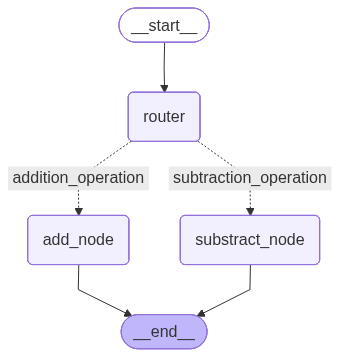

In [6]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
initial_state_1 = AgentState(number1=10, operation="+", number2=5)
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '+', 'number2': 5, 'result': 15}


In [8]:
initial_state_2 = AgentState(number1=10, operation="-", number2=5)
print(app.invoke(initial_state_2))

{'number1': 10, 'operation': '-', 'number2': 5, 'result': 5}


Exercise

In [15]:
class AgentState(TypedDict):
    number1: int
    operation1: str
    number2: int
    number3: int
    operation2: str
    number4: int
    finalNumber1: int
    finalNumber2: int

In [28]:
def adder1(state: AgentState) -> AgentState:
    """This node adds first two numbers"""
    state["finalNumber1"] = state["number1"] + state["number2"]
    return state

def subtractor1(state: AgentState) -> AgentState:
    """This node subtracts first two numbers"""
    state['finalNumber1'] = state["number1"] - state["number2"]
    return state

def decide_next_node1(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""
    if state['operation1'] == '+':
        return "addition_operation1"
    elif state['operation1'] == '-':
        return "subtraction_operation1"
    
def adder2(state: AgentState) -> AgentState:
    """This node adds second two numbers"""
    state["finalNumber2"] = state["number3"] + state["number4"]
    return state

def subtractor2(state: AgentState) -> AgentState:
    """This node subtracts second two numbers"""
    state['finalNumber2'] = state["number3"] - state["number4"]
    return state

def decide_next_node2(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""
    if state['operation2'] == '+':
        return "addition_operation2"
    elif state['operation2'] == '-':
        return "subtraction_operation2"

In [29]:
graph = StateGraph(AgentState)

graph.add_node("add_node1", adder1)
graph.add_node("substract_node1", subtractor1)
graph.add_node("router1", lambda state: state)

graph.add_node("add_node2", adder2)
graph.add_node("substract_node2", subtractor2)
graph.add_node("router2", lambda state: state)

graph.add_edge(START, "router1")
graph.add_conditional_edges(
    "router1",
    decide_next_node1,
    {
        "addition_operation1": "add_node1",
        "subtraction_operation1": "substract_node1"
    }
)
graph.add_edge("add_node1", "router2")
graph.add_edge("substract_node1", "router2")

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "addition_operation2": "add_node2",
        "subtraction_operation2": "substract_node2"
    }
)
graph.add_edge("add_node2", END)
graph.add_edge("substract_node2", END)

app = graph.compile()

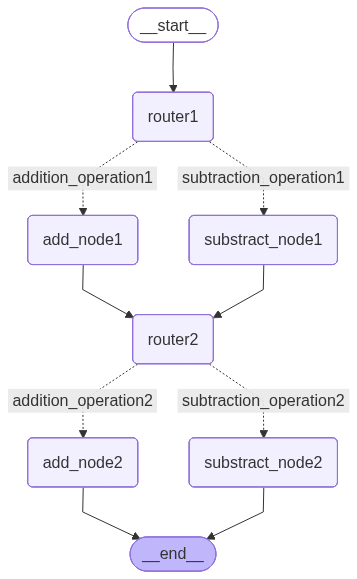

In [30]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [31]:
input_state = AgentState(number1=10, operation1="-", number2=5, number3=7, operation2="+", number4=2)

In [32]:
app.invoke(input_state)

{'number1': 10,
 'operation1': '-',
 'number2': 5,
 'number3': 7,
 'operation2': '+',
 'number4': 2,
 'finalNumber1': 5,
 'finalNumber2': 9}

In [33]:
input_state_2 = AgentState(number1=10, operation1="+", number2=5, number3=7, operation2="-", number4=2)
print(app.invoke(input_state_2))

{'number1': 10, 'operation1': '+', 'number2': 5, 'number3': 7, 'operation2': '-', 'number4': 2, 'finalNumber1': 15, 'finalNumber2': 5}
